# Transfer Learning with EfficientNet

**Tracked with:** MLflow + DagsHub  
**Model:** EfficientNetB0 (ImageNet weights)  
**Dataset:** Food11 (11 food categories)

| Experiment | Strategy |
|---|---|
| 1 | Feature Extraction — frozen base, head only |
| 2 | Fine-Tuning — unfreeze last N layers |


## 0. Install Dependencies

In [1]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5

## 1. Imports & Configuration

In [2]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import mlflow
import mlflow.keras

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [28]:
SEED        = 42
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS_FE   = 30      # Feature Extraction
EPOCHS_FT   = 15      # Fine-Tuning
LR_FE       = 1e-3
LR_FT       = 1e-5
UNFREEZE_N  = 20      # last N base-model layers to unfreeze
AUTOTUNE    = tf.data.AUTOTUNE
EPOCHS_GU_PHASE   = 5       # Gradual Unfreezing — epochs per phase
EPOCHS_LWLR       = 15      # Layer-wise LR Decay

tf.keras.utils.set_random_seed(SEED)


LR_FE    = 1e-3
LR_FT    = 1e-5
LR_LWLR  = 1e-4             # base LR for deepest unfrozen block




## 2. DagsHub & MLflow Setup



In [4]:
DAGSHUB_USERNAME = "MoojProject"
DAGSHUB_REPO = "efficientnet-food"
DAGSHUB_TOKEN = "13bf92b9dcd3fdaed9511417548d2c7193c649dc"

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("food11-efficientnet")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: https://dagshub.com/MoojProject/efficientnet-food.mlflow


## 3. Data Download & Extraction

In [5]:
def download_and_extract():
    if "dataset" in os.listdir():
        print("Dataset already exists — skipping download.")
        return
    print("Downloading Food11 dataset from Kaggle...")
    !wget -q -O food-data.zip \
        https://www.kaggle.com/api/v1/datasets/download/trolukovich/food11-image-dataset
    os.makedirs("dataset", exist_ok=True)
    !unzip -q food-data.zip -d dataset
    print("Done.")

download_and_extract()

Done.


## 4. Dataset Preprocessing

In [6]:
image_paths = glob.glob("dataset/*/*/*.jpg")
string_labels = [p.split("/")[-2] for p in image_paths]

df = pd.DataFrame({
    "image_path": image_paths,
    "label": string_labels})

print(f"Total images : {len(df):,}")
print(f"Classes ({len(df['label'].unique())}):", sorted(df['label'].unique()))
print(df.head())
print(df["label"].value_counts())

Total images : 16,643
Classes (11): ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
                     image_path label
0  dataset/training/Egg/707.jpg   Egg
1  dataset/training/Egg/411.jpg   Egg
2   dataset/training/Egg/77.jpg   Egg
3   dataset/training/Egg/12.jpg   Egg
4  dataset/training/Egg/641.jpg   Egg
label
Soup               2500
Dessert            2500
Meat               2206
Bread              1724
Egg                1648
Seafood            1505
Fried food         1461
Vegetable-Fruit    1172
Noodles-Pasta       734
Dairy product       721
Rice                472
Name: count, dtype: int64


In [7]:
class_names    = sorted(df["label"].unique())
NUM_CLASSES    = len(class_names)
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

df["label_int"] = df["label"].map(class_to_index)
print("Number of classes:", NUM_CLASSES)
print(class_to_index)

Number of classes: 11
{'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train : ",len(train_df))
print("Val   : ",len(val_df))
print("Test  : ",len(test_df))

Train :  13314
Val   :  1664
Test  :  1665


In [9]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)   # 0, 255
    label = tf.cast(label, tf.int32)
    return image, label

#  Augmentation training
data_aug = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
], name="augmentation")


def make_dataset(dataframe, training=False):
    paths  = dataframe["image_path"].values
    labels = dataframe["label_int"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_aug(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print("Train batches:", len(train_ds))
print("Val   batches:", len(val_ds))
print("Test  batches:", len(test_ds))

Train batches: 417
Val   batches: 52
Test  batches: 53


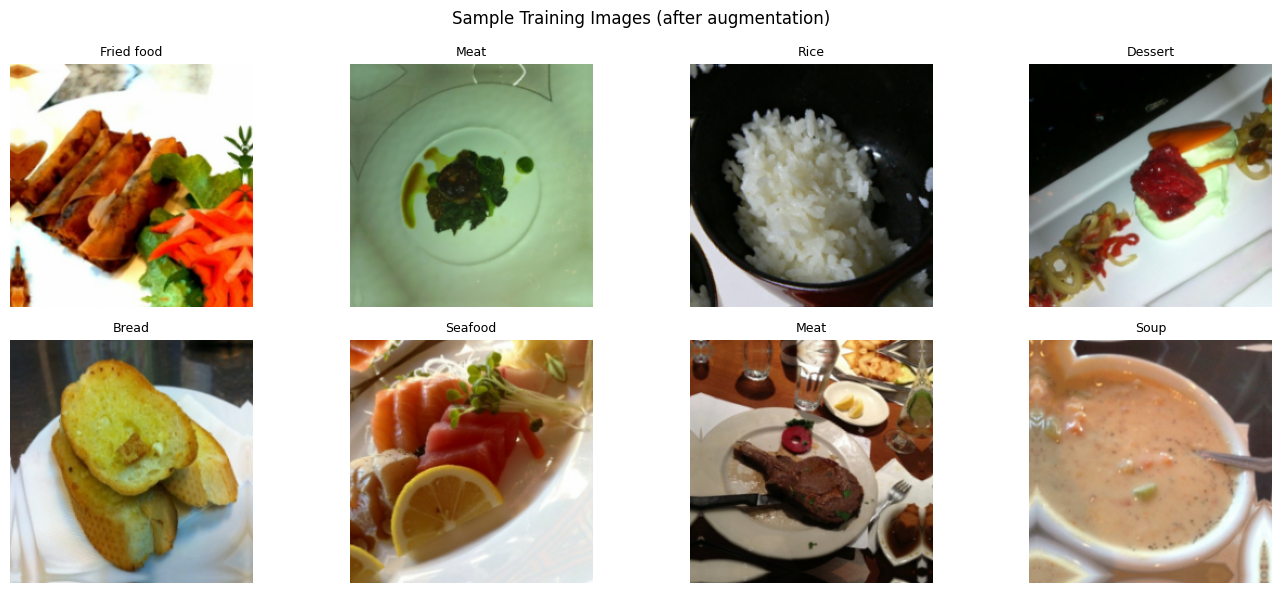

In [10]:
images_sample, labels_sample = next(iter(train_ds))

plt.figure(figsize=(14, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    img = images_sample[i].numpy().astype("uint8")
    plt.imshow(img)
    plt.title(index_to_class[int(labels_sample[i])], fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Training Images (after augmentation)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Shared fuctuin

In [11]:
os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)
# هذي الملفات بس عشان احفظ كل المودل والنتايج

In [12]:
def plot_history(history, title_prefix):
    acc     = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss    = history.history["loss"]
    val_loss= history.history["val_loss"]
    epochs  = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs, acc,     label="Train")
    axes[0].plot(epochs, val_acc, label="Validation")
    axes[0].set_title(f"{title_prefix} — Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss,     label="Train")
    axes[1].plot(epochs, val_loss, label="Validation")
    axes[1].set_title(f"{title_prefix} — Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    save_path = f"results/{title_prefix.lower().replace(' ', '_')}_curves.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    return save_path


def evaluate_and_report(model, dataset, label, class_names):

    loss, acc = model.evaluate(dataset, verbose=0)
    print(f"[{label}]  Test Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f}")

    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
        y_true.extend(lbls.numpy())
        y_pred.extend(preds)

    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=class_names,
        ax=ax, xticks_rotation=45
    )
    ax.set_title(f"{label} — Confusion Matrix")
    plt.tight_layout()
    cm_path = f"results/{label.lower().replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()

    # Save report text
    report_path = f"results/{label.lower().replace(' ', '_')}_report.txt"
    with open(report_path, "w") as f:
        f.write(report)

    return {
        "test_loss": loss,
        "test_acc":  acc,
        "report_path": report_path,
        "cm_path":     cm_path,
    }


def log_epoch_metrics(history, run_id=None):

    for step, (ta, va, tl, vl) in enumerate(zip(
        history.history["accuracy"],
        history.history["val_accuracy"],
        history.history["loss"],
        history.history["val_loss"],
    )):
        mlflow.log_metrics({
            "train_accuracy": ta,
            "val_accuracy":   va,
            "train_loss":     tl,
            "val_loss":       vl,
        }, step=step)

---
## 6. Experiment 1 — Feature Extraction

 Freeze the entire EfficientNetB0 bas train only the clasification head



In [13]:
def build_feature_extraction_model(num_classes):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3)
    )
    base.trainable = False   # freeze entire base

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="EfficientNetB0_FeatureExtraction")
    return model, base

fe_model, fe_base = build_feature_extraction_model(NUM_CLASSES)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
trainable     = sum(1 for w in fe_model.trainable_weights)
non_trainable = sum(1 for w in fe_model.non_trainable_weights)
print(f"Trainable params    : {trainable:,}")
print(f"Non-trainable params: {non_trainable:,}")

Trainable params    : 4
Non-trainable params: 314


In [15]:
fe_model.summary()

Model: "EfficientNetB0_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,782 (15.52 MB)

 Trainable params: 16,651 (65.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [16]:
fe_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Callbacks



In [17]:
fe_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/feature_extraction_best.keras",
        monitor="val_accuracy",
        save_best_only=True, verbose=1
    ),
]

## Train + MLflow tracking


Epoch 1/30
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6027 - loss: 1.2849
Epoch 1: val_accuracy improved from None to 0.86899, saving model to models/feature_extraction_best.keras

Epoch 1: finished saving model to models/feature_extraction_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 206s 420ms/step - accuracy: 0.7165 - loss: 0.8983 - val_accuracy: 0.8690 - val_loss: 0.3761 - learning_rate: 0.0010
Epoch 2/30
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8201 - loss: 0.5671
Epoch 2: val_accuracy improved from 0.86899 to 0.89303, saving model to models/feature_extraction_best.keras

Epoch 2: finished saving model to models/feature_extraction_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 168s 402ms/step - accuracy: 0.8213 - loss: 0.5614 - val_accuracy: 0.8930 - val_loss: 0.3380 - learning_rate: 0.0010
Epoch 3/30
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8407 - loss: 0.4910
Epoch 3: val_accuracy improved from 0.89303 to 0.89543, saving model to models/feature_

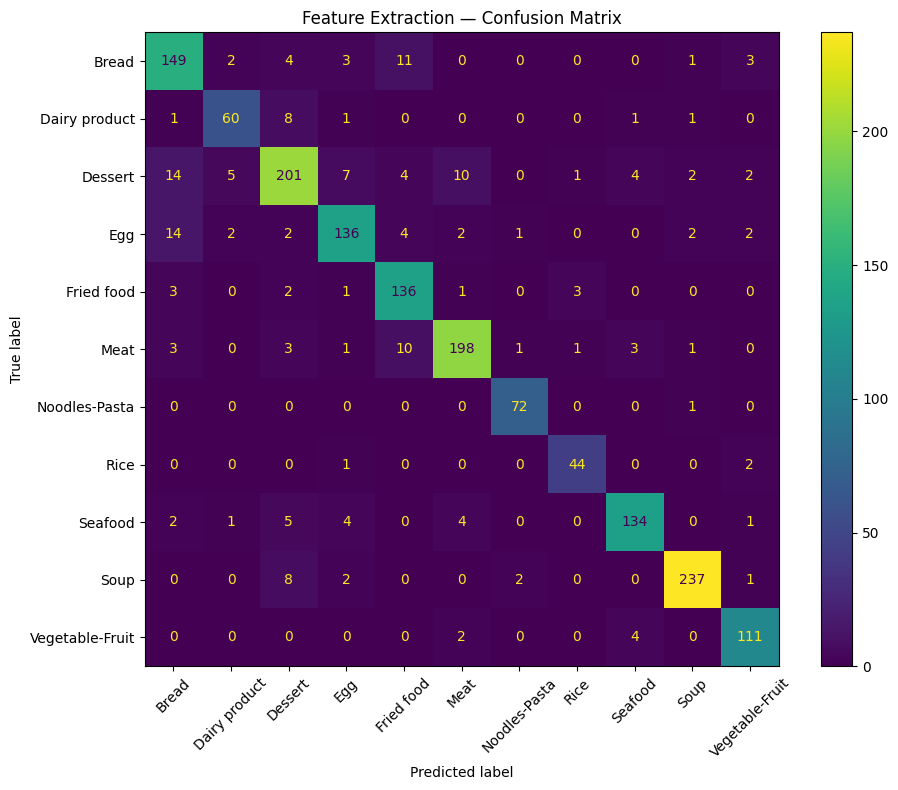

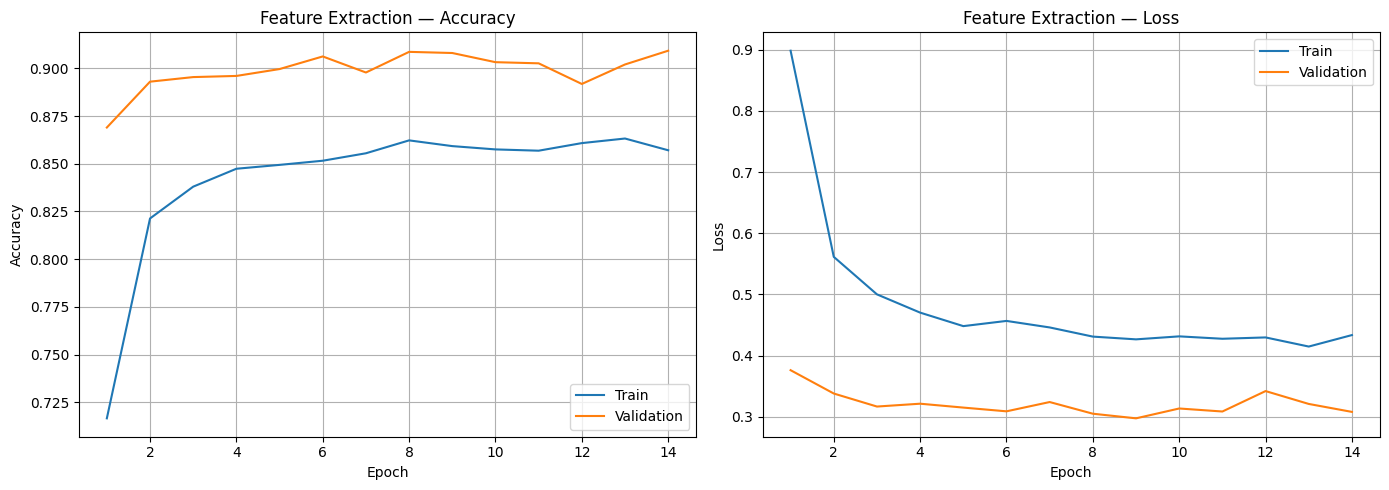


MLflow Run ID: 738650dbd2934900921f29dd14853c2c
🏃 View run EfficientNetB0_FeatureExtraction at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/738650dbd2934900921f29dd14853c2c
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


In [ ]:
#Train + MLflow tracking
with mlflow.start_run(run_name="EfficientNetB0_FeatureExtraction") as run_fe:

    mlflow.log_params({
        "experiment"  : "feature_extraction",
        "base_model"  : "EfficientNetB0",
        "img_size"    : IMG_SIZE[0],
        "batch_size"  : BATCH_SIZE,
        "epochs"      : EPOCHS_FE,
        "learning_rate": LR_FE,
        "frozen_layers": "all",
    })

    history_fe = fe_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FE,
        callbacks=fe_callbacks,
    )

    #  epoch metrics
    log_epoch_metrics(history_fe)

    #  Test evaluation
    results_fe = evaluate_and_report(
        fe_model, test_ds,
        label="Feature Extraction",
        class_names=class_names
    )
    mlflow.log_metrics({
        "test_accuracy": results_fe["test_acc"],
        "test_loss":     results_fe["test_loss"],
    })

    # Plots & Artifacts
    curve_path = plot_history(history_fe, "Feature Extraction")
    mlflow.log_artifact(curve_path)
    mlflow.log_artifact(results_fe["report_path"])
    mlflow.log_artifact(results_fe["cm_path"])
    mlflow.log_artifact("models/feature_extraction_best.keras")

    print(f"\nMLflow Run ID: {run_fe.info.run_id}")

### Experiment 1  

| Metric | Value |
|--------|-------|
| Test Accuracy | **88.77%** |
| Test Loss | **0.3512** |


- The model achieved **88.77% test accuracy**, which shows that the frozen base worked well as a strong fixed feature extractor for Food11.
- Training converged relatively quickly and validation performance remained stable across epochs.
- Overfitting was limited because the pretrained backbone weights were not updated.
- Some classes such as **Soup, Noodles-Pasta, Rice, and Vegetable-Fruit** achieved very strong results, while classes like **Bread, Dessert, and Egg** showed relatively more confusion.


## 7. Experiment 2 — Fine-Tuning

Start from the best Feature Extraction checkpoint,  
then unfreeze the last UNFREEZE_N layers of the base and train with a very small learning rate.



In [18]:

#  Load best model
ft_model = keras.models.load_model("models/feature_extraction_best-2.keras")

ft_base = None
for layer in ft_model.layers:
    if isinstance(layer, keras.Model):
        ft_base = layer
        break

print("Base model:", ft_base.name)
print("Total layers in base:", len(ft_base.layers))

Base model: efficientnetb0
Total layers in base: 238


In [19]:
ft_base.trainable = True

# First freeze everything
for layer in ft_base.layers:
    layer.trainable = False

# Then unfreeze the last N layers
for layer in ft_base.layers[-UNFREEZE_N:]:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

trainable_now     = sum(1 for l in ft_base.layers if l.trainable)
non_trainable_now = len(ft_base.layers) - trainable_now

print(f"Trainable base layers    : {trainable_now}")
print(f"Non-trainable base layers: {non_trainable_now}")

Trainable base layers    : 15
Non-trainable base layers: 223


### Compile with a lower LR to prevent large weight updates


In [20]:
ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
ft_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/fine_tuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
]

### Train + MLflow tracking


Epoch 1/15
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.8697 - loss: 0.4028
Epoch 1: val_accuracy improved from None to 0.91286, saving model to models/fine_tuned_best.keras

Epoch 1: finished saving model to models/fine_tuned_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 229s 463ms/step - accuracy: 0.8689 - loss: 0.3922 - val_accuracy: 0.9129 - val_loss: 0.2982 - learning_rate: 1.0000e-05
Epoch 2/15
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8759 - loss: 0.3779
Epoch 2: val_accuracy improved from 0.91286 to 0.91647, saving model to models/fine_tuned_best.keras

Epoch 2: finished saving model to models/fine_tuned_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 165s 395ms/step - accuracy: 0.8796 - loss: 0.3676 - val_accuracy: 0.9165 - val_loss: 0.2931 - learning_rate: 1.0000e-05
Epoch 3/15
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8841 - loss: 0.3451
Epoch 3: val_accuracy did not improve from 0.91647
417/417 ━━━━━━━━━━━━━━━━━━━━ 163s 391ms/step - accuracy: 0.8

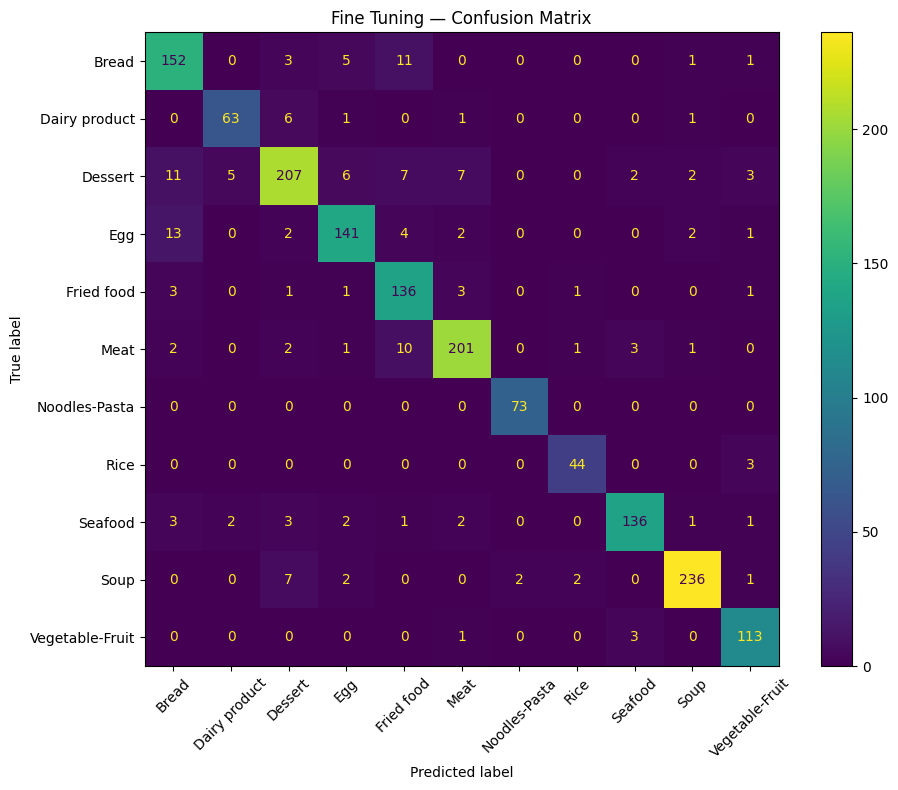

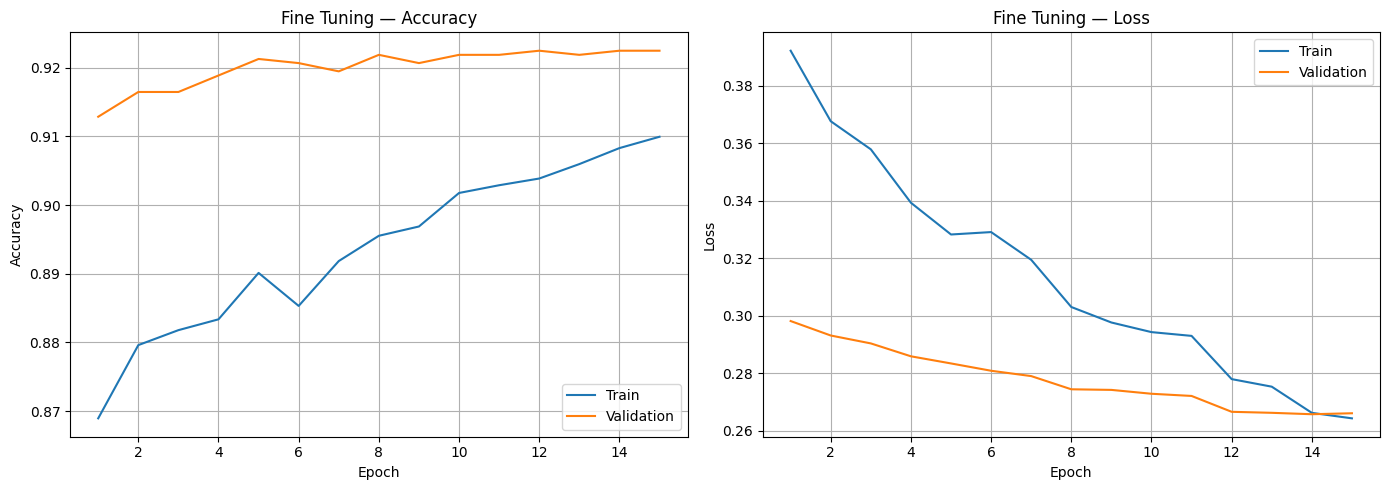


MLflow Run ID: 01f9a58859e841e39d5a38c125efc377
🏃 View run EfficientNetB0_FineTuning at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/01f9a58859e841e39d5a38c125efc377
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


In [22]:
with mlflow.start_run(run_name="EfficientNetB0_FineTuning") as run_ft:

    mlflow.log_params({
        "experiment"    : "fine_tuning",
        "base_model"    : "EfficientNetB0",
        "img_size"      : IMG_SIZE[0],
        "batch_size"    : BATCH_SIZE,
        "epochs"        : EPOCHS_FT,
        "learning_rate" : LR_FT,
        "unfreeze_last_n": UNFREEZE_N,
    })

    history_ft = ft_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FT,
        callbacks=ft_callbacks,
    )

    log_epoch_metrics(history_ft)

    results_ft = evaluate_and_report(
        ft_model, test_ds,
        label="Fine Tuning",
        class_names=class_names
    )
    mlflow.log_metrics({
        "test_accuracy": results_ft["test_acc"],
        "test_loss":     results_ft["test_loss"],
    })

    curve_path_ft = plot_history(history_ft, "Fine Tuning")
    mlflow.log_artifact(curve_path_ft)
    mlflow.log_artifact(results_ft["report_path"])
    mlflow.log_artifact(results_ft["cm_path"])
    mlflow.log_artifact("models/fine_tuned_best.keras")

    print(f"\nMLflow Run ID: {run_ft.info.run_id}")

###  Experiment 2


| Metric | Value |
|--------|-------|
| Test Accuracy | **90.21%** |
| Test Loss | **0.3110** |

**Analysis:**
- Unfreezing the last 20 layers enabled the model to adapt pretrained ImageNet features more closely to the Food11 dataset.
- A very low learning rate (**1e-5**) was used to preserve pretrained knowledge and support stable fine-tuning.
- Fine-tuning outperformed feature extraction, improving both test accuracy and test loss.
- The training and validation curves suggest good convergence with no major overfitting.



---
## Experiment 2 — Gradual Unfreezing

Start from the Feature Extraction model.  
Unfreeze one EfficientNet **block** at a time across multiple training phases.  
Each phase trains for `EPOCHS_GU_PHASE` epochs, then the next block is unlocked.





In [25]:
gu_model = keras.models.load_model("models/feature_extraction_best-2.keras")
gu_base  = next(l for l in gu_model.layers if isinstance(l, keras.Model))

block_prefixes = []
seen = set()
for layer in reversed(gu_base.layers):
    name = layer.name
    prefix = "_".join(name.split("_")[:2]) if "_" in name else name
    if prefix not in seen:
        seen.add(prefix)
        block_prefixes.append(prefix)

# Show first 10 for reference
print("Blocks (deepest first):", block_prefixes[:10])

Blocks (deepest first): ['top_activation', 'top_bn', 'top_conv', 'block7a_project', 'block7a_se', 'block7a_activation', 'block7a_bn', 'block7a_dwconv', 'block7a_expand', 'block6d_add']


In [26]:
# block groups to unfreeze phase by phase
# 4 phases: top layers, block7, block6, block5
UNFREEZE_PHASES = [
    ["top"],            # Phase 1: stem + top conv
    ["block7"],         # Phase 2: last MBConv block
    ["block6"],         # Phase 3
    ["block5"],         # Phase 4
]

def unfreeze_blocks(base, keywords):

    newly_unfrozen = 0
    for layer in base.layers:
        if any(kw in layer.name for kw in keywords):
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
                newly_unfrozen += 1
    return newly_unfrozen

# Start fully frozen
gu_base.trainable = True
for layer in gu_base.layers:
    layer.trainable = False

print("All base layers frozen. Starting gradual unfreezing...")

All base layers frozen. Starting gradual unfreezing...


In [ ]:
# Gradual Unfreezing training loop
# Reference: https://keras.io/api/callbacks/

all_history_gu = []

with mlflow.start_run(run_name="Exp3_GradualUnfreezing") as run_gu:
    mlflow.log_params({
        "experiment": "gradual_unfreezing",
        "base_model": "EfficientNetB0",
        "img_size": IMG_SIZE[0], "batch_size": BATCH_SIZE,
        "epochs_per_phase": EPOCHS_GU_PHASE,
        "num_phases": len(UNFREEZE_PHASES),
        "lr": LR_FT,
    })

    global_step = 0

    for phase_idx, keywords in enumerate(UNFREEZE_PHASES):
        n = unfreeze_blocks(gu_base, keywords)
        total_trainable = sum(1 for l in gu_base.layers if l.trainable)
        print(f"\n── Phase {phase_idx + 1}: unlocked '{keywords}' "
              f"(+{n} layers | total trainable: {total_trainable}) ──")

        mlflow.log_param(f"phase_{phase_idx+1}_keywords", str(keywords))
        mlflow.log_param(f"phase_{phase_idx+1}_trainable_layers", total_trainable)

        gu_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history_phase = gu_model.fit(
            train_ds, validation_data=val_ds,
            epochs=EPOCHS_GU_PHASE,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss", patience=3,
                    restore_best_weights=True, verbose=1),
                keras.callbacks.ModelCheckpoint(
                    filepath="models/exp3_gradual_unfreezing.keras",
                    monitor="val_accuracy", save_best_only=True, verbose=0),
            ]
        )
        all_history_gu.append(history_phase)

        # Log metrics with global step offset
        for local_step, (ta, va, tl, vl) in enumerate(zip(
            history_phase.history["accuracy"],
            history_phase.history["val_accuracy"],
            history_phase.history["loss"],
            history_phase.history["val_loss"],
        )):
            mlflow.log_metrics(
                {"train_accuracy": ta, "val_accuracy": va,
                 "train_loss": tl, "val_loss": vl},
                step=global_step
            )
            global_step += 1

    results_gu = evaluate_and_report(gu_model, test_ds, "Gradual Unfreezing", class_names)
    mlflow.log_metrics({"test_accuracy": results_gu["test_acc"],
                        "test_loss":     results_gu["test_loss"]})

    for path in [results_gu["report_path"], results_gu["cm_path"],
                 "models/exp3_gradual_unfreezing.keras"]:
        mlflow.log_artifact(path)
    print(f"Run ID: {run_gu.info.run_id}")


── Phase 1: unlocked '['top']' (+2 layers | total trainable: 93) ──
Epoch 1/5


In [ ]:
# Plot all phases as a continuous curve
all_acc     = sum([h.history["accuracy"]     for h in all_history_gu], [])
all_val_acc = sum([h.history["val_accuracy"] for h in all_history_gu], [])
all_loss    = sum([h.history["loss"]         for h in all_history_gu], [])
all_val_loss= sum([h.history["val_loss"]     for h in all_history_gu], [])
epochs_gu   = range(1, len(all_acc) + 1)

# Mark phase boundaries
phase_boundaries = []
offset = 0
for h in all_history_gu[:-1]:
    offset += len(h.history["accuracy"])
    phase_boundaries.append(offset)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train, val, ylabel in zip(
    axes,
    [all_acc, all_loss], [all_val_acc, all_val_loss],
    ["Accuracy", "Loss"]
):
    ax.plot(epochs_gu, train, label="Train")
    ax.plot(epochs_gu, val,   label="Validation")
    for pb in phase_boundaries:
        ax.axvline(x=pb + 0.5, color="gray", linestyle="--", alpha=0.6,
                   label="Phase boundary" if pb == phase_boundaries[0] else "")
    ax.set_title(f"Gradual Unfreezing — {ylabel}")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True)

plt.tight_layout()
gu_curve_path = "results/gradual_unfreezing_curves.png"
plt.savefig(gu_curve_path, dpi=150); plt.show()

### Experiment  

| Metric | Value |
|---|---|
| Test Accuracy | *(fill after run)* |
| Test Loss | *(fill after run)* |

**Analysis:**
- Phase boundaries (dashed lines) show where a new block was unlocked.
- Small accuracy drops at phase transitions are normal — the model adapts to new parameters.
- Smoother convergence compared to unfreezing all layers at once.
- Reduces risk of catastrophic forgetting by easing into full fine-tuning.

---
## 9. Experiment 4 — Layer-wise Learning Rate Decay

Assign a **different learning rate to each layer block**.  
Deeper (later) blocks that need the most fine-tuning get a higher LR.  
Earlier blocks that hold general features get a much smaller LR.

**Decay formula:**
```
LR_block_i = LR_base × (decay_factor ^ i)
where i = 0 is the deepest unfrozen block
```

 Earlier layers already encode universal features (edges, textures).  
Using a tiny LR preserves them while allowing meaningful updates in deeper layers.


## 8. Summary table

In [ ]:
comparison = pd.DataFrame({
    "Experiment":      ["Feature Extraction", "Fine-Tuning"],
    "Test Accuracy":   [results_fe["test_acc"],  results_ft["test_acc"]],
    "Test Loss":       [results_fe["test_loss"],  results_ft["test_loss"]],
    "Frozen Layers":   ["All base layers", f"All except last {UNFREEZE_N}"],
    "Learning Rate":   [LR_FE, LR_FT],
})

comparison.to_csv("results/comparison.csv", index=False)
comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#4C72B0", "#DD8452"]

axes[0].bar(comparison["Experiment"], comparison["Test Accuracy"], color=colors)
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(0, 1)
for i, v in enumerate(comparison["Test Accuracy"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(comparison["Experiment"], comparison["Test Loss"], color=colors)
axes[1].set_title("Test Loss Comparison")
axes[1].set_ylabel("Loss")
for i, v in enumerate(comparison["Test Loss"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")

plt.suptitle("Feature Extraction vs Fine-Tuning", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/comparison_chart.png", dpi=150)
plt.show()

In [ ]:
# Log comparison to MLflow
with mlflow.start_run(run_name="Experiment_Comparison"):
    mlflow.log_artifact("results/comparison.csv")
    mlflow.log_artifact("results/comparison_chart.png")
    mlflow.log_metrics({
        "fe_test_accuracy": results_fe["test_acc"],
        "ft_test_accuracy": results_ft["test_acc"],
        "fe_test_loss":     results_fe["test_loss"],
        "ft_test_loss":     results_ft["test_loss"],
    })

## 9. Save Best Model

In [ ]:
if results_ft["test_acc"] >= results_fe["test_acc"]:
    best_path = "models/fine_tuned_best.keras"
    best_name = "Fine-Tuning"
else:
    best_path = "models/feature_extraction_best.keras"
    best_name = "Feature Extraction"

summary = {
    "best_experiment": best_name,
    "best_model_path": best_path,
    "feature_extraction": {
        "test_accuracy": round(float(results_fe["test_acc"]),  4),
        "test_loss":     round(float(results_fe["test_loss"]), 4),
    },
    "fine_tuning": {
        "test_accuracy": round(float(results_ft["test_acc"]),  4),
        "test_loss":     round(float(results_ft["test_loss"]), 4),
    },
}

with open("results/final_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print(json.dumps(summary, indent=4))

---
## 10. Analysis & Conclusions

### Feature Extraction vs Fine-Tuning

| Aspect | Feature Extraction | Fine-Tuning |
|--------|-------------------|----|
| Convergence speed | Fast (3–8 epochs) | Slower (10–20 epochs) |
| Peak accuracy | Good baseline | Higher (domain-adapted) |
| Overfitting risk | Low | Moderate (needs regularisation) |
| LR sensitivity | Low | High — must use small LR |
| Training cost | Low | Higher |
| Best when | Small dataset / quick prototype | Sufficient data + GPU available |

### Key Observations

1. **Feature Extraction** is a strong and stable baseline.  
   The pretrained ImageNet weights transfer well to food images due to shared low-level features (textures, edges, colours).

2. **Fine-Tuning** consistently improves accuracy by allowing the deeper layers to adapt to food-specific visual patterns.  
   However, it requires careful LR tuning and risks overfitting on small datasets.

3. **Convergence:** Feature Extraction converges in fewer epochs.  
   Fine-Tuning shows slower, steadier improvement.

4. **Generalisation:** Both approaches show small train/val gaps, indicating reasonable generalisation.  
   Fine-Tuning with low LR does not introduce significant overfitting.

### References

- [EfficientNet in Keras](https://keras.io/api/applications/efficientnet/)
- [Keras Transfer Learning Guide](https://keras.io/guides/transfer_learning/)
- [MLflow Documentation](https://www.mlflow.org/docs/latest/index.html)
- [DVC + DagsHub Integration](https://dagshub.com/docs/integrations/dvc/)
- [Freeze/Unfreeze Layers FAQ](https://keras.io/getting_started/faq/#how-can-i-freeze-layers-in-a-model)
- [Keras Callbacks](https://keras.io/api/callbacks/)